# **First project!**

## **About**
This is our first project. What we will do here is first split our data into training and testing data.This will be a Supervised Learning Model. Particularly in Supervised Learning, we will be using linear regression to solve it. \
But remember one thing, the linear regression will be used only on the training set (linear regression is fitting a line in the data)!

# **Loading the dataset**

This is the very first step! What you do in the very first is start loading the dataset. It is done by calling the *pandas* library beacuse it is designed for data manipulation and analysis.  It is primarily used to work with structured, tabular data through its core data structures: the DataFrame (2D labeled table) and the Series (1D labeled array).

(Here, '*df*' is the acronym of '*dataframe*')





---


> **What is a DataFrame**?
A Pandas DataFrame is a two-dimensional, labeled data structure used for
storing and manipulating structured data, similar to a spreadsheet or SQL table.  It consists of rows (representing records) and columns (representing variables), where each column can hold different data types such as integers, floats, or strings.


---
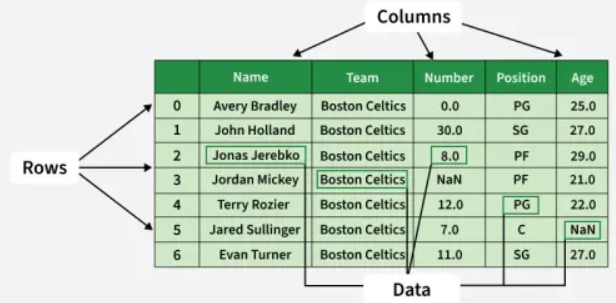

In [1]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/delaney_solubility_with_descriptors.csv')
df

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


The next step is the seperation of the input variables from the output variables. What happens generally is that the last column is always the *'Dependent Variable'* or *'Output Variable'* or our *'y-variable'*; while the remaining columns are the *'Input Variables'*.

# **Data Preparation**

## **Data Seperation as x and y**

In [2]:
y = df['logS']
y

,logS
0,-2.180
1,-2.000
2,-1.740
3,-1.480
4,-3.040
...,...
1139,1.144
1140,-4.925
1141,-3.893
1142,-3.790


For input, instead of typing all the input variables in 'df[]' function, we will use the ***drop*** function!

---
Why using a ***drop*** function instead of 'df[]'?
Well the answer to that is it is easy for us to seperate the input while using 'drop' because what drop does is it simply removes the column [if axis=1] or row [if axis=0].

---

In [3]:
#For example, if you want to drop the first row, you will write df.drop(1, axis=0)
x = df.drop('logS', axis=1)
x

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
0,2.59540,167.850,0.0,0.000000
1,2.37650,133.405,0.0,0.000000
2,2.59380,167.850,1.0,0.000000
3,2.02890,133.405,1.0,0.000000
4,2.91890,187.375,1.0,0.000000
...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000
1140,3.42130,286.114,2.0,0.333333
1141,3.60960,308.333,4.0,0.695652
1142,2.56214,354.815,3.0,0.521739


## **Holdout Cross Validation Technique**
I split my data using the Holdout method (e.g., 80% train, 20% test).\
\
Holdout Validation simply decides which data the algorithm is allowed to look at. It hides a portion of your data (the test set) in a locked drawer so you can check the model's math later.

In [4]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)

***test_size=0.2*** means that the size of the testing data has to be 20% of the whole data.\
***random_state=100*** - This acts as a "seed" for the random number generator. Because the function shuffles your data before splitting it, setting a specific random_state ensures that the data is shuffled the exact same way every time you run the code. This makes your results reproducible.\
With random_state=100: The computer still shuffles the deck randomly, but it locks in that exact shuffle. No matter how many times you run the code, or if you send your code to a colleague on the other side of the world, the data will always split in the exact same way.

In [5]:
x_train

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
107,3.14280,112.216,5.0,0.000000
378,-2.07850,142.070,0.0,0.000000
529,-0.47730,168.152,0.0,0.000000
546,-0.86740,154.125,0.0,0.000000
320,1.62150,100.161,2.0,0.000000
...,...,...,...,...
802,3.00254,250.301,1.0,0.842105
53,2.13860,82.146,3.0,0.000000
350,5.76304,256.348,0.0,0.900000
79,3.89960,186.339,10.0,0.000000


In [6]:
x_train

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
107,3.14280,112.216,5.0,0.000000
378,-2.07850,142.070,0.0,0.000000
529,-0.47730,168.152,0.0,0.000000
546,-0.86740,154.125,0.0,0.000000
320,1.62150,100.161,2.0,0.000000
...,...,...,...,...
802,3.00254,250.301,1.0,0.842105
53,2.13860,82.146,3.0,0.000000
350,5.76304,256.348,0.0,0.900000
79,3.89960,186.339,10.0,0.000000


In [7]:
y_train

,logS
107,-4.440
378,-1.250
529,-1.655
546,-1.886
320,-0.740
...,...
802,-2.925
53,-2.680
350,-7.020
79,-4.800


In [8]:
y_test

,logS
822,-3.380
118,-8.010
347,-2.160
1123,-1.170
924,-0.730
...,...
1114,-4.130
427,-9.018
711,-0.600
4,-3.040


# **Model Building**

After seperating the data as training and testing; for this example, we will use Holdout Cross Validation Technique to train out ML model.

## **Method-1: Linear Regression**

Linear Regression is a fundamental statistical and machine learning algorithm used when your target variable (what you want to predict) is continuous—like predicting house prices, stock values, or temperature. It works by mapping a linear relationship between your input features ($X$) and the continuous output ($Y$), fitting a line defined by the classic equation:$$Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \dots + \beta_nX_n + \epsilon$$

### **Training the model on training data**


In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
lr

LinearRegression()

### **Applying the model to make a prediction**

#### **Predicting the values of our training data**

In [10]:
y_lr_train_pred = lr.predict(x_train)
y_lr_train_pred

array([-2.83668969,  0.84208401, -0.50930302, -0.13058053, -1.6269208 ,
       -2.86103037, -2.32208333, -4.16684323, -5.04235077, -2.29737009,
       -3.15082845, -4.33037208, -1.43700682, -2.59060064, -7.09025955,
       -2.32734557, -4.19073421, -2.63904005, -3.58104074, -3.75929058,
       -2.5501665 , -3.26968347, -2.78911367, -2.69251051, -0.77437547,
       -6.61955792, -2.99084623, -2.36975061, -7.18167736, -1.52816491,
       -4.81736265, -0.86996608, -7.09025955, -1.87404275, -2.58013247,
       -4.80953284, -4.17454084, -1.95444152, -3.50503339, -2.7411418 ,
       -1.87131835, -2.45270806, -3.07252433, -1.48988982, -3.98778754,
       -1.35216679, -0.16932277, -6.05237002, -3.29550658,  0.30513174,
       -3.25501463, -5.31993586, -0.4733928 , -4.79180882, -5.82486323,
       -2.70343539, -3.70838271, -2.4987341 , -2.12301018, -3.11393974,
       -2.79842053, -1.38274662, -4.3267103 , -3.57778946, -3.42356884,
       -9.15826626, -6.52588866, -1.75832085, -4.97842312, -1.59

What we did above is we predicted the 80% of our total data.

#### **Predicting the values of our testing data**

In [11]:
y_lr_test_pred = lr.predict(x_test)
y_lr_test_pred

array([-3.05722870e+00, -7.77785827e+00, -2.55016650e+00, -2.01523582e+00,
       -2.06375990e+00, -9.99672215e-01, -5.94603364e-01, -5.53626003e-01,
       -5.72200956e+00, -3.94006681e+00, -3.95496755e+00, -2.29737009e+00,
       -1.48980354e+00, -1.48988982e+00, -4.64510806e+00, -1.90396018e+00,
       -1.51566313e+00, -3.16424605e+00, -3.70863920e+00, -5.58105660e+00,
       -3.25038467e+00, -5.04235077e+00, -5.69194881e+00, -2.14339849e+00,
       -4.35689341e+00, -5.03964756e+00, -3.10383618e+00, -4.40286964e+00,
       -4.21276272e+00,  5.56508349e-01, -1.45537678e+00, -4.41027396e+00,
       -2.59668773e+00, -1.53336276e+00, -5.55749874e-01, -1.67111795e+00,
       -2.78163675e+00, -3.15395565e+00, -5.27083361e+00, -1.75321446e+00,
       -1.53350725e+00, -2.01255666e+00, -6.57559167e+00, -7.89433046e+00,
       -5.76437127e+00, -4.16422068e+00, -3.43694663e+00,  1.43834212e+00,
       -1.12679105e-02, -2.34521849e+00, -1.86480046e+00, -5.03964756e+00,
        8.55886378e-01, -

What we did above is we predicted the remaining 20% of our data

### **Evaluating model performance**

The next step in the process is we will be checking the difference between the predicted values and the actual values to evaluate the performance.

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
#MSE for the training set
lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

#MSE for the testing set
lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)


In [13]:
lr_train_mse

1.0075362951093687

In [14]:
lr_train_r2

0.7645051774663391

In [15]:
lr_test_mse

1.0206953660861033

In [16]:
lr_test_r2

0.7891616188563282

So we can make it tidy a little bit.

In [17]:
print('LR_MSE (train) = ', lr_train_mse)
print('LR_r2 (train) = ', lr_train_r2)
print('LR_MSE (test) = ', lr_test_mse)
print('LR_r2 (test) = ', lr_test_r2)

LR_MSE (train) =  1.0075362951093687
LR_r2 (train) =  0.7645051774663391
LR_MSE (test) =  1.0206953660861033
LR_r2 (test) =  0.7891616188563282


Making it a little bit more clean

In [18]:
lr_results = pd.DataFrame(['Linear Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results

,0,1,2,3,4
0,Linear Regression,1.007536,0.764505,1.020695,0.789162


In [19]:
#Changing the names of the columns
lr_results.columns = ['Method','Training MSE', 'Training R2', 'Testing MSE', 'Testing R2']
lr_results

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear Regression,1.007536,0.764505,1.020695,0.789162


## **Method-2: Random Forest**

### **Training the Model on training data**

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(x_train, y_train)
rf

RandomForestRegressor(max_depth=2, random_state=100)

We used the Regression version of the Random Forest because the y values are quantitative; if it would have been non-quantitative values, we would be using the classfication model

### **Applying the model to make a prediction**


#### **Predicting the value of our training data**

In [21]:
y_rf_train_pred = rf.predict(x_train)
y_rf_train_pred

array([-4.44388581, -1.40132433, -1.41481453, -1.41481453, -1.44411435,
       -2.67492782, -2.50755276, -3.95611327, -4.62529592, -2.27343298,
       -2.69241199, -4.5150244 , -1.41481453, -2.67492782, -7.14501987,
       -2.30422396, -4.0676017 , -3.36086239, -2.53282364, -4.5150244 ,
       -2.47178242, -4.0676017 , -2.66143763, -1.42912192, -1.2164651 ,
       -7.14501987, -2.67492782, -2.47178242, -7.14501987, -1.2164651 ,
       -4.5150244 , -1.2164651 , -7.14501987, -1.41481453, -1.64246378,
       -4.5150244 , -4.5150244 , -1.41481453, -2.71012897, -1.64246378,
       -2.42959807, -2.89446137, -2.47178242, -1.24495146, -2.69241199,
       -1.2164651 , -1.2164651 , -4.65157679, -2.6279475 , -1.2164651 ,
       -1.79134844, -4.5150244 , -1.2164651 , -4.44388581, -4.62529592,
       -4.0676017 , -4.5150244 , -2.66143763, -1.41481453, -4.0676017 ,
       -2.67492782, -1.40132433, -3.32568382, -2.51725697, -4.44388581,
       -7.14501987, -7.14501987, -1.44411435, -4.5150244 , -1.42

#### **Predicting the value of our testing data**

In [24]:
y_rf_test_pred = rf.predict(x_test)
y_rf_test_pred

array([-3.97313718, -7.14501987, -2.47178242, -2.40196468, -1.44411435,
       -1.40132433, -1.2164651 , -1.41481453, -7.14501987, -4.5150244 ,
       -4.5150244 , -2.27343298, -1.83979246, -1.24495146, -4.5150244 ,
       -1.40132433, -1.24495146, -2.67492782, -2.67492782, -4.65157679,
       -3.00915981, -4.62529592, -7.12312525, -2.47657839, -4.5150244 ,
       -4.5150244 , -4.5150244 , -4.5150244 , -4.44388581, -1.2164651 ,
       -1.41481453, -2.67492782, -2.67492782, -1.42961706, -1.40132433,
       -2.27343298, -2.0381419 , -2.67492782, -4.5150244 , -1.38740573,
       -1.2164651 , -1.61447629, -7.14501987, -7.14501987, -7.12312525,
       -4.42408609, -2.0381419 , -1.41481453, -1.41481453, -2.50541484,
       -1.83979246, -4.5150244 , -1.2164651 , -2.6279475 , -4.62529592,
       -1.42912192, -7.14501987, -1.2164651 , -1.41481453, -4.62529592,
       -1.62796649, -2.69241199, -2.67492782, -2.66143763, -1.2164651 ,
       -1.23077249, -2.67492782, -4.00999869, -1.41481453, -4.21

### **Evaluating model performance**

In [25]:
from sklearn.metrics import mean_squared_error, r2_score
#MSE for the training set
rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)

#MSE for the testing set
rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)


In [26]:
rf_results = pd.DataFrame(['Random Forest', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results

,0,1,2,3,4
0,Random Forest,1.028228,0.759669,1.407688,0.709223


In [27]:
#Changing the names of the columns
rf_results.columns = ['Method','Training MSE', 'Training R2', 'Testing MSE', 'Testing R2']
rf_results

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Random Forest,1.028228,0.759669,1.407688,0.709223


## **Model Comparison**

In [34]:
df.models = pd.concat([lr_results, rf_results], axis=0)
# We made axis=0 because we wanted to merge row-wise
df.models

# Changing the indexes now
  ## Without using (drop=True):
###df.models.reset_index()
  ## Using (drop=True)
df.models.reset_index(drop=True)

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear Regression,1.007536,0.764505,1.020695,0.789162
1,Random Forest,1.028228,0.759669,1.407688,0.709223


## **Data Visualization of prediction results**

Text(0.5, 0, 'Experimental logS')

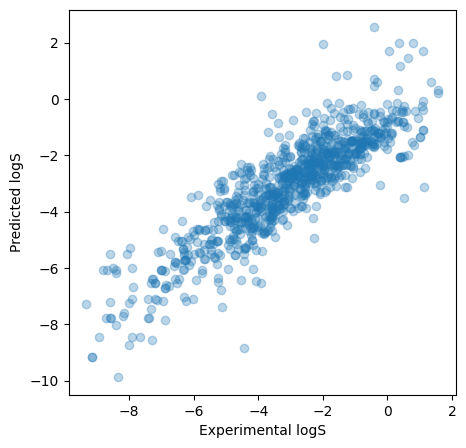

In [37]:
import matplotlib.pyplot as plt
# For a square plot
plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=y_lr_train_pred, alpha=0.3)

plt.plot()
plt.ylabel('Predicted logS')
plt.xlabel('Experimental logS')

Text(0.5, 0, 'Experimental logS')

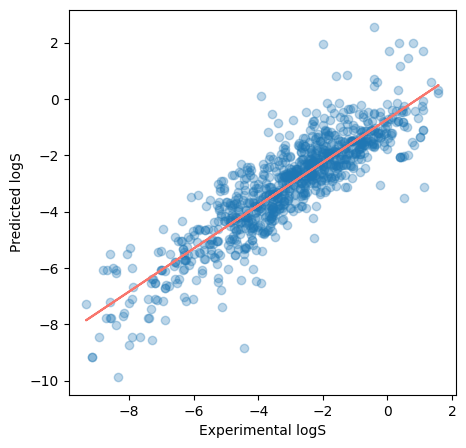

In [43]:
# For a line to be fitted in this (Linear Regression)

import matplotlib.pyplot as plt
import numpy as np

# For a square plot
plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=y_lr_train_pred, alpha=0.3)

z = np.polyfit(y_train, y_lr_train_pred, 1)
p = np.poly1d(z)

plt.plot(y_train, p(y_train), '#F8766D')
plt.ylabel('Predicted logS')
plt.xlabel('Experimental logS')